# Diabetes Prediction ML Model

In [66]:
import numpy as np,pandas as pd, matplotlib.pyplot as plt,seaborn as sns

In [67]:
df=pd.read_csv('diabetes_prediction_dataset.csv')

In [68]:
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [69]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [70]:
df.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [71]:
df.ndim

2

In [72]:
df.shape

(100000, 9)

In [73]:
df.size

900000

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


# Data Processing

In [75]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [76]:
df.duplicated().sum()

3854

In [77]:
df.drop_duplicates(inplace=True)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96146 non-null  object 
 1   age                  96146 non-null  float64
 2   hypertension         96146 non-null  int64  
 3   heart_disease        96146 non-null  int64  
 4   smoking_history      96146 non-null  object 
 5   bmi                  96146 non-null  float64
 6   HbA1c_level          96146 non-null  float64
 7   blood_glucose_level  96146 non-null  int64  
 8   diabetes             96146 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 7.3+ MB


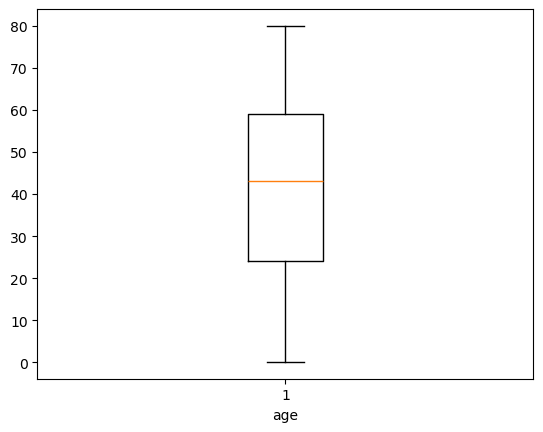

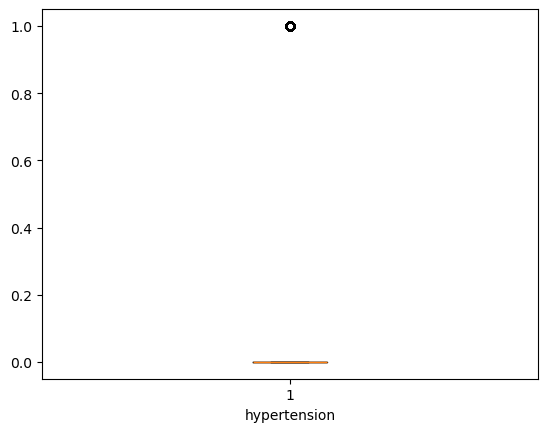

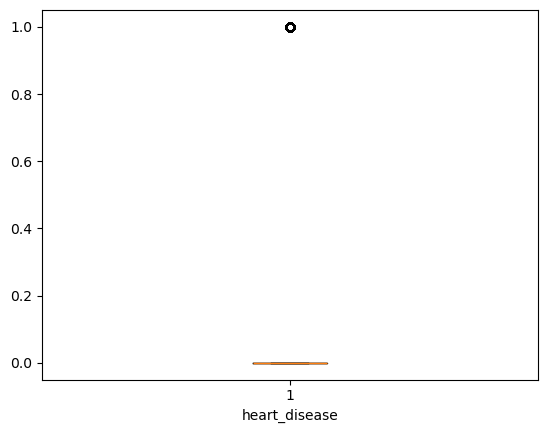

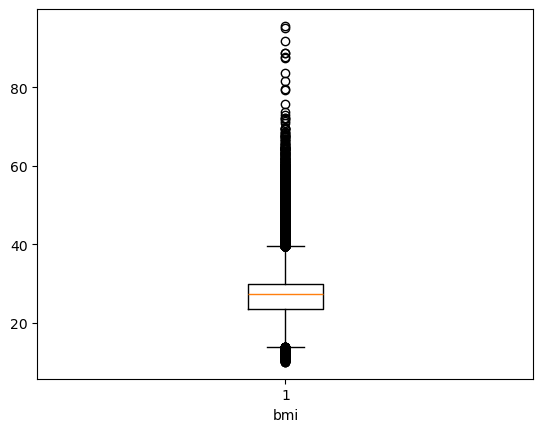

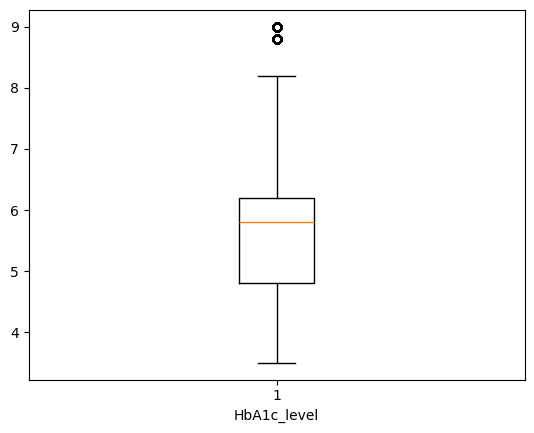

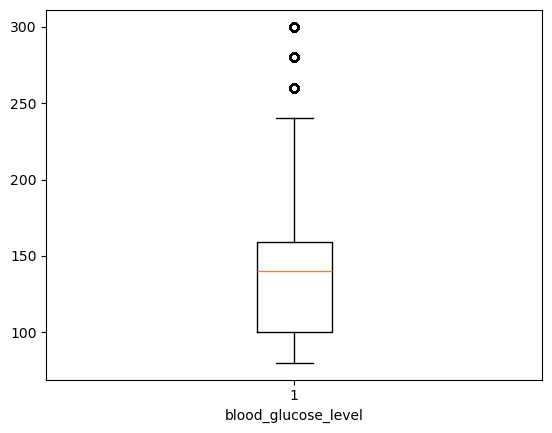

In [79]:
for i in df.columns:
    if((df[i].dtypes!='object')&(i!='diabetes')):
        plt.boxplot(df[i])
        plt.xlabel(i)
        plt.show()

In [80]:
out_col=['bmi','HbA1c_level','blood_glucose_level']

In [81]:
out_col

['bmi', 'HbA1c_level', 'blood_glucose_level']

In [82]:
for i in out_col:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    iqr=q3-q1
    lb=q1-iqr*1.5
    ub=q3+iqr*1.5
    df=df[(df[i]>=lb)&(df[i]<=ub)]

In [83]:
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99994,Female,36.0,0,0,No Info,24.60,4.8,145,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [84]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [85]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in df.columns:
    if(df[i].dtypes=='object'):
        df[i]=le.fit_transform(df[i])
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0


In [86]:
import warnings
warnings.filterwarnings("ignore")

# Data visualization

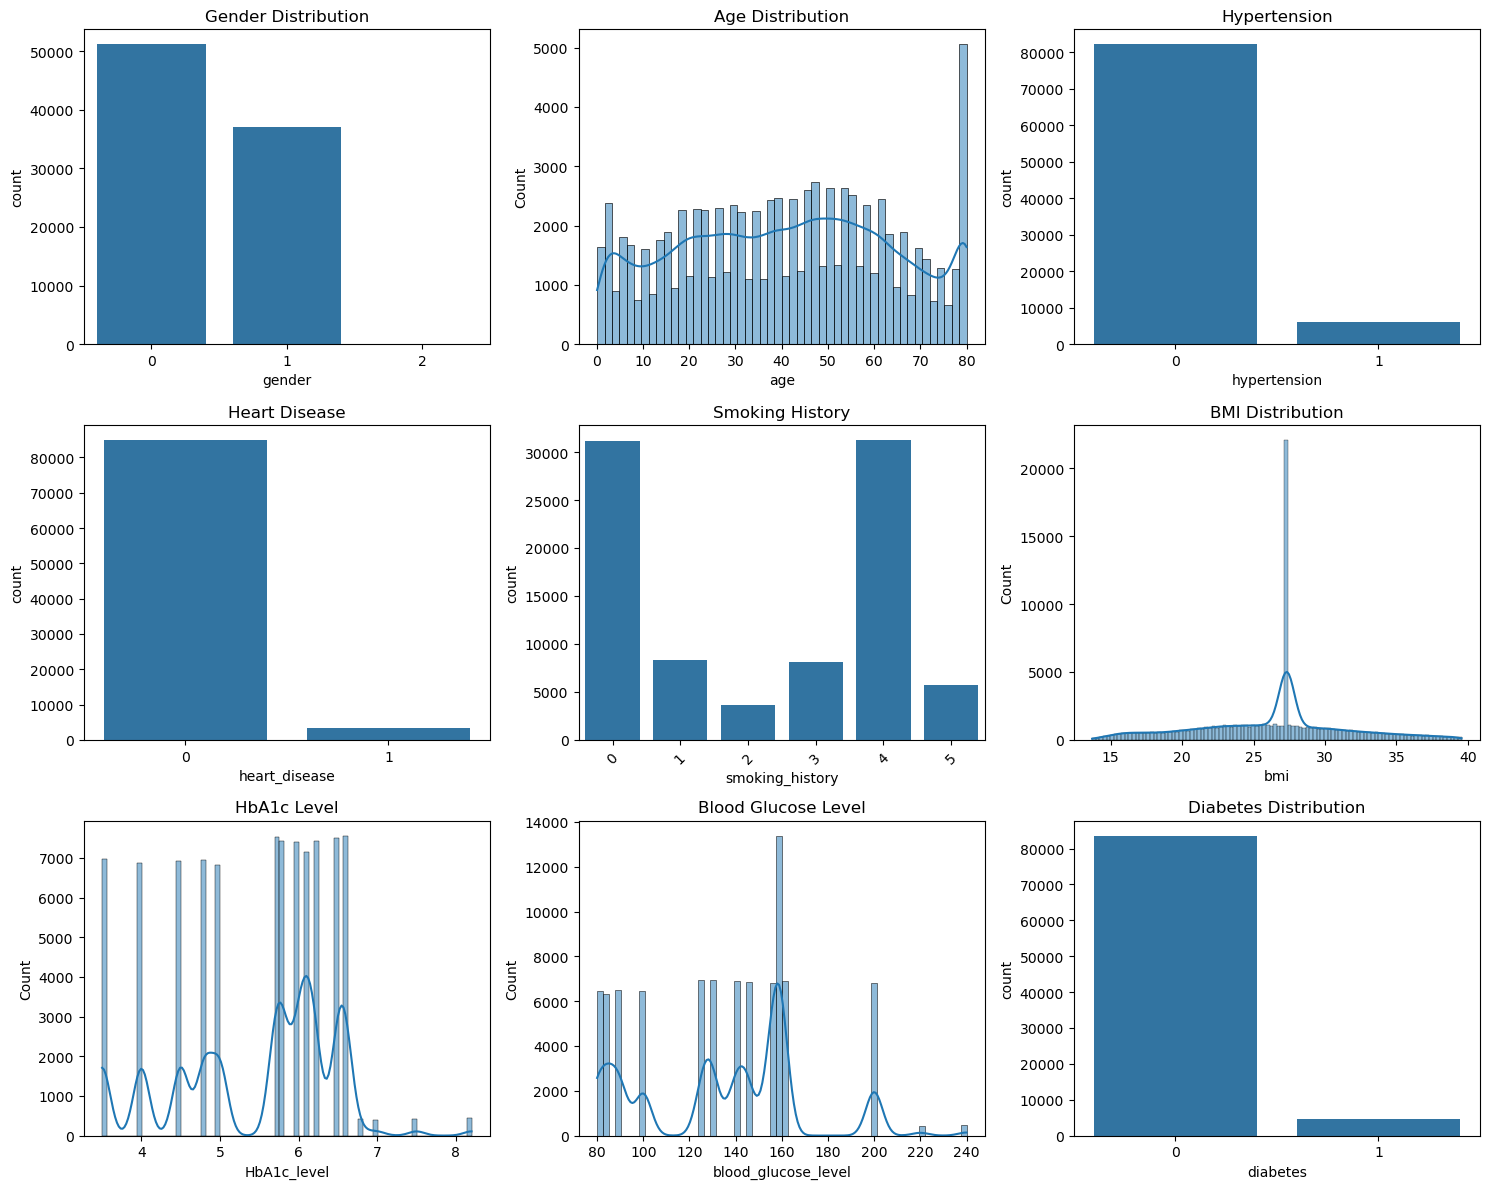

In [87]:
plt.figure(figsize=(15, 12))

# 1. Gender (Categorical)
plt.subplot(3, 3, 1)
sns.countplot(x=df.gender)
plt.title("Gender Distribution")

# 2. Age (Numerical)
plt.subplot(3, 3, 2)
sns.histplot(df.age, kde=True)
plt.title("Age Distribution")

# 3. Hypertension (Categorical)
plt.subplot(3, 3, 3)
sns.countplot(x=df.hypertension)
plt.title("Hypertension")

# 4. Heart Disease (Categorical)
plt.subplot(3, 3, 4)
sns.countplot(x=df.heart_disease)
plt.title("Heart Disease")

# 5. Smoking History (Categorical)
plt.subplot(3, 3, 5)
sns.countplot(x=df.smoking_history)
plt.title("Smoking History")
plt.xticks(rotation=45)

# 6. BMI (Numerical)
plt.subplot(3, 3, 6)
sns.histplot(df.bmi, kde=True)
plt.title("BMI Distribution")

# 7. HbA1c Level (Numerical)
plt.subplot(3, 3, 7)
sns.histplot(df.HbA1c_level, kde=True)
plt.title("HbA1c Level")

# 8. Blood Glucose Level (Numerical)
plt.subplot(3, 3, 8)
sns.histplot(df.blood_glucose_level, kde=True)
plt.title("Blood Glucose Level")

# 9. Diabetes (Target Variable)
plt.subplot(3, 3, 9)
sns.countplot(x=df.diabetes)
plt.title("Diabetes Distribution")

plt.tight_layout()
plt.show()


In [88]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
cols=[]
for i in df.columns:
    if(i!='diabetes'):
        cols.append(i)
x=df[cols]
vif=pd.DataFrame()
vif['Features']=x.columns
vif['VIF']=[variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif

,Features,VIF
0,gender,1.737179
1,age,5.850281
2,hypertension,1.151404
3,heart_disease,1.113282
4,smoking_history,2.537968
5,bmi,22.404575
6,HbA1c_level,19.050518
7,blood_glucose_level,13.004871


In [89]:
df=df.drop('bmi',axis=1)

In [90]:
df

,gender,age,hypertension,heart_disease,smoking_history,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,6.6,140,0
1,0,54.0,0,0,0,6.6,80,0
2,1,28.0,0,0,4,5.7,158,0
3,0,36.0,0,0,1,5.0,155,0
4,1,76.0,1,1,1,4.8,155,0
...,...,...,...,...,...,...,...,...
99994,0,36.0,0,0,0,4.8,145,0
99996,0,2.0,0,0,0,6.5,100,0
99997,1,66.0,0,0,3,5.7,155,0
99998,0,24.0,0,0,4,4.0,100,0


In [91]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
cols=[]
for i in df.columns:
    if(i!='diabetes'):
        cols.append(i)
x=df[cols]
vif=pd.DataFrame()
vif['Features']=x.columns
vif['VIF']=[variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif

,Features,VIF
0,gender,1.718050
1,age,4.922246
2,hypertension,1.151332
3,heart_disease,1.109044
4,smoking_history,2.482546
5,HbA1c_level,13.277752
6,blood_glucose_level,11.708336


In [92]:
df=df.drop('HbA1c_level',axis=1)

In [93]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
cols=[]
for i in df.columns:
    if(i!='diabetes'):
        cols.append(i)
x=df[cols]
vif=pd.DataFrame()
vif['Features']=x.columns
vif['VIF']=[variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif

,Features,VIF
0,gender,1.666276
1,age,4.522618
2,hypertension,1.149731
3,heart_disease,1.106907
4,smoking_history,2.434032
5,blood_glucose_level,4.675242


In [94]:
x

,gender,age,hypertension,heart_disease,smoking_history,blood_glucose_level
0,0,80.0,0,1,4,140
1,0,54.0,0,0,0,80
2,1,28.0,0,0,4,158
3,0,36.0,0,0,1,155
4,1,76.0,1,1,1,155
...,...,...,...,...,...,...
99994,0,36.0,0,0,0,145
99996,0,2.0,0,0,0,100
99997,1,66.0,0,0,3,155
99998,0,24.0,0,0,4,100


In [95]:
y=df['diabetes']
y

0        0
1        0
2        0
3        0
4        0
        ..
99994    0
99996    0
99997    0
99998    0
99999    0
Name: diabetes, Length: 88195, dtype: int64

In [96]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.75,random_state=30)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(66146, 6)
(22049, 6)
(66146,)
(22049,)


In [97]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [98]:
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [99]:
y_pred=model.predict(x_test)

In [100]:
acc=accuracy_score(y_pred,y_test)
print(f"Accuracy score:{acc*100}")

Accuracy score:95.24694997505556


In [101]:
cm=confusion_matrix(y_pred,y_test)
print(cm)

[[20852   988]
 [   60   149]]


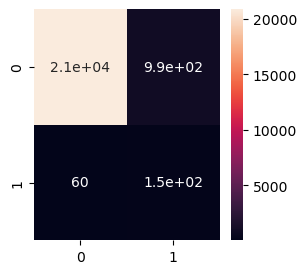

In [102]:
plt.figure(figsize=(3,3))
sns.heatmap(cm,annot=True)
plt.show()

In [103]:
report=classification_report(y_pred,y_test)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.95      0.98     21840
           1       0.13      0.71      0.22       209

    accuracy                           0.95     22049
   macro avg       0.56      0.83      0.60     22049
weighted avg       0.99      0.95      0.97     22049



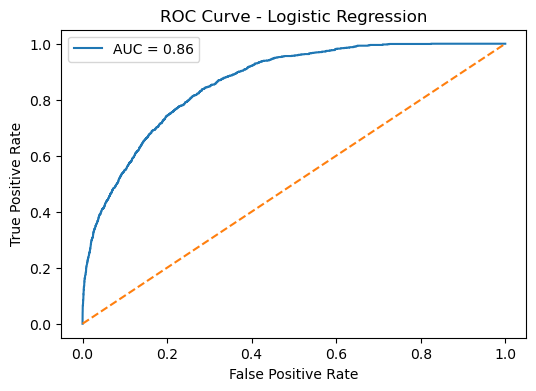

In [123]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Train pipeline
pipe.fit(x_train, y_train)

# Get probabilities
y_prob = pipe.predict_proba(x_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()


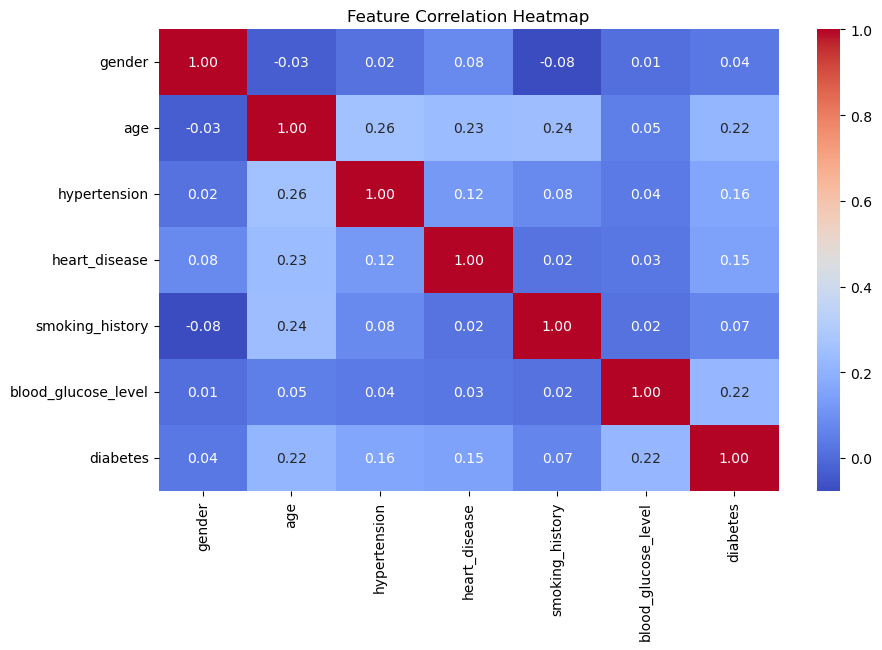

In [104]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


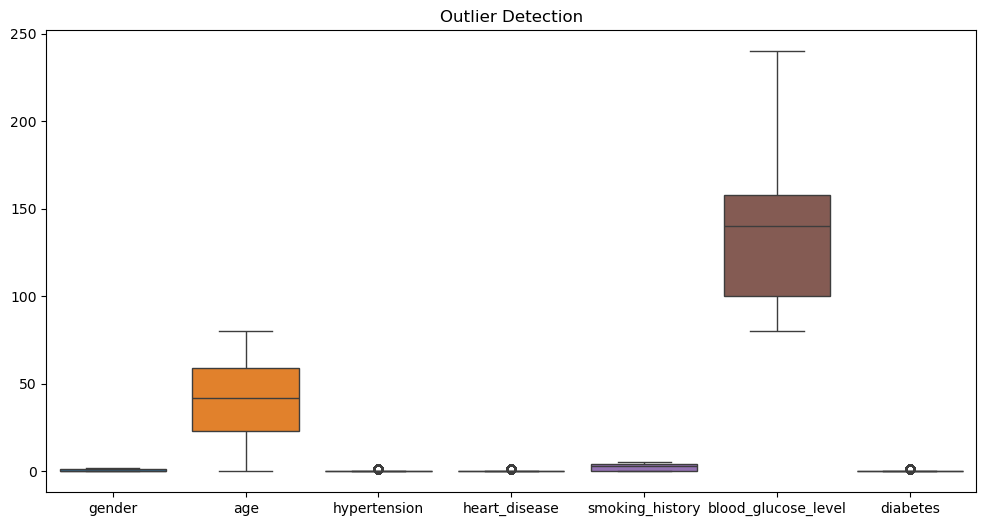

In [105]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['gender','age','hypertension','heart_disease','smoking_history','blood_glucose_level','diabetes']])
plt.title("Outlier Detection")
plt.show()


In [106]:
df['diabetes'].value_counts(normalize=True)


diabetes
0    0.947639
1    0.052361
Name: proportion, dtype: float64

In [110]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000))
])


In [108]:
pipe

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(class_weight='balanced'))])

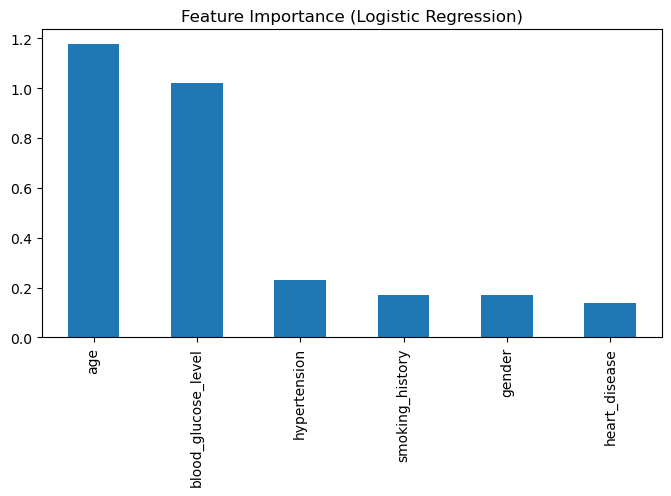

In [121]:
import pandas as pd

feature_importance = pd.Series(
    pipe.named_steps['model'].coef_[0],
    index=x_train.columns
).sort_values(key=abs, ascending=False)

feature_importance.plot(kind='bar', figsize=(8,4))
plt.title("Feature Importance (Logistic Regression)")
plt.show()


## Conclusion
- Logistic Regression with feature scaling performed well on the diabetes dataset.
- The model achieved a strong F1-score, indicating good class balance handling.
- Blood glucose level and HbA1c were the most influential predictors.
- This model can assist in early diabetes risk screening but is not a medical diagnostic tool.
